# Delineate and mask fast ice on InSAR GeoTIFFs

This notebook selects the nearest dated fast-ice GeoTIFF and aligns category `4`
with each InSAR GeoTIFF. For every input GeoTIFF it creates:

1. an RGB display GeoTIFF with the fast-ice boundary shown in red; and
2. a quantitative, single-band GeoTIFF retaining values only inside fast ice.

The output rasters use the exact CRS, transform, width, and height of the input
InSAR GeoTIFF. The fast-ice GeoTIFF supplies the source CRS and transform.


In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import rasterio
from rasterio.warp import reproject, Resampling
import matplotlib.pyplot as plt
import re


## 1. Inputs

Set the paths and required date. The nearest `FastIce_70_YYYYMMDD.tif` file
will be selected automatically.


In [2]:
geotiff_dir = Path(
    "/Volumes/shared/Sci-EAE/lahuang_work/working/Shackleton1/test_IW1/merged/"
)
fast_ice_tif_dir = Path("/Users/lhua0106/Library/CloudStorage/Dropbox-MonashUniEnterprise/Lanqing Huang/Monash2026/fastice/Large_py_output/FastIce_70_2017")

input_date = "2017-06-15"
fast_ice_category = 4
boundary_width_pixels = 2

output_dir = Path("./output/")
output_dir.mkdir(parents=True, exist_ok=True)

tif_files = [
    "filt_topophase_phase_geo.tif",
    "topophase_amp_geo.tif",
    "topophase_coherence_geo.tif",
]

print(f"Outputs will be saved in:\n{output_dir.resolve()}")


Outputs will be saved in:
/Users/lhua0106/Library/CloudStorage/Dropbox-MonashUniEnterprise/Lanqing Huang/Code_projects/Monash-working/Fastice_analyses/output


## 2. Select the nearest fast-ice GeoTIFF


In [3]:
date_pattern = re.compile(r"FastIce_70_(\d{8})\.tif$", re.IGNORECASE)
fast_ice_candidates = []

for path in fast_ice_tif_dir.glob("*.tif"):
    match = date_pattern.match(path.name)
    if match:
        fast_ice_candidates.append(
            (path, pd.to_datetime(match.group(1), format="%Y%m%d"))
        )

if not fast_ice_candidates:
    raise FileNotFoundError(
        f"No FastIce_70_YYYYMMDD.tif files found in {fast_ice_tif_dir.resolve()}"
    )

target_date = pd.Timestamp(input_date)
selected_fast_ice_tif, selected_date = min(
    fast_ice_candidates,
    key=lambda item: abs(item[1] - target_date),
)

print(f"Requested date: {target_date:%Y-%m-%d}")
print(f"Selected date:  {selected_date:%Y-%m-%d}")
print(f"Selected file:  {selected_fast_ice_tif}")


Requested date: 2017-06-15
Selected date:  2017-06-15
Selected file:  /Users/lhua0106/Library/CloudStorage/Dropbox-MonashUniEnterprise/Lanqing Huang/Monash2026/fastice/Large_py_output/FastIce_70_2017/FastIce_70_20170615.tif


## 3. Read the selected fast-ice GeoTIFF

The exported GeoTIFF must contain a valid CRS and affine transform. No NetCDF
coordinate assumptions are used.


In [4]:
with rasterio.open(selected_fast_ice_tif) as fast_src:
    if fast_src.crs is None:
        raise ValueError(
            f"{selected_fast_ice_tif.name} has no CRS. "
            "Assign/export the correct CRS in QGIS first."
        )

    fast_ice_data = fast_src.read(1, masked=True)
    source_mask = (
        (~np.ma.getmaskarray(fast_ice_data))
        & (np.asarray(fast_ice_data.data) == fast_ice_category)
    ).astype("uint8")
    source_transform = fast_src.transform
    source_crs = fast_src.crs
    source_bounds = fast_src.bounds
    source_resolution = fast_src.res

print(f"Fast-ice CRS: {source_crs}")
print(f"Fast-ice resolution: {source_resolution}")
print(f"Fast-ice bounds: {source_bounds}")
print(f"Class-{fast_ice_category} pixels: {source_mask.sum():,}")

if source_mask.sum() == 0:
    with rasterio.open(selected_fast_ice_tif) as fast_src:
        values = fast_src.read(1, masked=True).compressed()
    print(f"Available values: {np.unique(values)}")
    raise ValueError(
        f"No pixels equal category {fast_ice_category} in "
        f"{selected_fast_ice_tif.name}."
    )


Fast-ice CRS: EPSG:3976
Fast-ice resolution: (999.9999999660067, 999.9999999650754)
Fast-ice bounds: BoundingBox(left=-2691054.59660408, bottom=-2390155.59751664, right=2933945.4032047084, top=2309844.4023192143)
Class-4 pixels: 464,065


## 4. Alignment and boundary helpers

The mask is reprojected directly onto each input GeoTIFF's grid using nearest
neighbour resampling, which is appropriate for categorical data.


In [5]:
def erode_binary(mask):
    padded = np.pad(mask, 1, mode="constant", constant_values=False)
    neighbours = [
        padded[row:row + mask.shape[0], col:col + mask.shape[1]]
        for row in range(3)
        for col in range(3)
    ]
    return np.logical_and.reduce(neighbours)


def dilate_binary(mask, iterations):
    result = mask.copy()
    for _ in range(iterations):
        padded = np.pad(result, 1, mode="constant", constant_values=False)
        neighbours = [
            padded[row:row + result.shape[0], col:col + result.shape[1]]
            for row in range(3)
            for col in range(3)
        ]
        result = np.logical_or.reduce(neighbours)
    return result


def mask_on_reference_grid(src):
    destination = np.zeros((src.height, src.width), dtype="uint8")
    reproject(
        source=source_mask,
        destination=destination,
        src_transform=source_transform,
        src_crs=source_crs,
        dst_transform=src.transform,
        dst_crs=src.crs,
        src_nodata=0,
        dst_nodata=0,
        resampling=Resampling.nearest,
        init_dest_nodata=True,
    )
    return destination == 1


## 5. Create the two products

`*_fast_ice_boundary.tif` is an RGB visualization.  
`*_fast_ice_only.tif` remains a single-band quantitative raster: pixels outside
class `4` are NoData (`NaN`), while original values inside class `4` are kept.


In [6]:
for tif_name in tif_files:
    input_tif = geotiff_dir / tif_name

    if not input_tif.exists():
        print(f"Not found, skipped: {input_tif}")
        continue

    with rasterio.open(input_tif) as src:
        if src.crs is None:
            raise ValueError(f"{input_tif.name} has no CRS.")

        raster = src.read(1, masked=True)
        data = raster.filled(np.nan).astype("float32")
        valid = ~np.ma.getmaskarray(raster) & np.isfinite(data)
        fast_ice_on_tif = mask_on_reference_grid(src)

        print(f"\n{input_tif.name}")
        print(f"  GeoTIFF CRS: {src.crs}")
        print(f"  GeoTIFF bounds: {src.bounds}")
        print(f"  Class-4 pixels on GeoTIFF grid: {fast_ice_on_tif.sum():,}")

        if not fast_ice_on_tif.any():
            print("  Warning: no overlap. Compare the printed CRS and bounds.")

        # Product 1: RGB visualization with a red fast-ice boundary.
        boundary = fast_ice_on_tif & ~erode_binary(fast_ice_on_tif)
        if boundary_width_pixels > 1:
            boundary = dilate_binary(boundary, boundary_width_pixels - 1)

        if "phase" in tif_name and "amp" not in tif_name:
            vmin, vmax, cmap = -np.pi, np.pi, "twilight"
        elif "coherence" in tif_name:
            vmin, vmax, cmap = 0.0, 1.0, "viridis"
        else:
            finite_values = data[valid]
            if finite_values.size == 0:
                raise ValueError(f"{input_tif.name} contains no valid pixels.")
            vmin, vmax = np.nanpercentile(finite_values, [2, 98])
            cmap = "gray"

        if not np.isfinite(vmin) or not np.isfinite(vmax) or vmax <= vmin:
            raise ValueError(f"Invalid display range for {input_tif.name}: {vmin}, {vmax}")

        scaled = np.clip((data - vmin) / (vmax - vmin), 0, 1)
        rgb = (plt.get_cmap(cmap)(scaled)[..., :3] * 255).astype("uint8")
        rgb[~valid] = [0, 0, 0]
        rgb[boundary & valid] = [255, 0, 0]

        boundary_tif = output_dir / f"{input_tif.stem}_fast_ice_boundary.tif"
        rgb_profile = src.profile.copy()
        rgb_profile.update(
            count=3,
            dtype="uint8",
            nodata=None,
            compress="deflate",
            photometric="RGB",
        )
        with rasterio.open(boundary_tif, "w", **rgb_profile) as dst:
            dst.write(np.moveaxis(rgb, 2, 0))
            dst.set_band_description(1, "Red")
            dst.set_band_description(2, "Green")
            dst.set_band_description(3, "Blue")
            dst.update_tags(
                fast_ice_class=str(fast_ice_category),
                fast_ice_date=f"{selected_date:%Y-%m-%d}",
                boundary_colour="red",
            )

        # Product 2: original values only within class-4 fast ice.
        keep = valid & fast_ice_on_tif
        masked_data = np.where(keep, data, np.nan).astype("float32")
        masked_tif = output_dir / f"{input_tif.stem}_fast_ice_only.tif"

        mask_profile = src.profile.copy()
        mask_profile.update(
            count=1,
            dtype="float32",
            nodata=np.nan,
            compress="deflate",
        )
        with rasterio.open(masked_tif, "w", **mask_profile) as dst:
            dst.write(masked_data, 1)
            dst.set_band_description(1, f"{src.descriptions[0] or input_tif.stem} - fast ice only")
            dst.update_tags(
                fast_ice_class=str(fast_ice_category),
                fast_ice_date=f"{selected_date:%Y-%m-%d}",
            )

    print(f"  Saved boundary: {boundary_tif.name}")
    print(f"  Saved masked raster: {masked_tif.name}")

print("\nDone.")



filt_topophase_phase_geo.tif
  GeoTIFF CRS: EPSG:4326
  GeoTIFF bounds: BoundingBox(left=97.18833333333333, bottom=-66.68916666666667, right=101.00055555555555, top=-64.89527777777778)
  Class-4 pixels on GeoTIFF grid: 7,191,110
  Saved boundary: filt_topophase_phase_geo_fast_ice_boundary.tif
  Saved masked raster: filt_topophase_phase_geo_fast_ice_only.tif

topophase_amp_geo.tif
  GeoTIFF CRS: EPSG:4326
  GeoTIFF bounds: BoundingBox(left=97.18833333333333, bottom=-66.68916666666667, right=101.00055555555555, top=-64.89527777777778)
  Class-4 pixels on GeoTIFF grid: 7,191,110
  Saved boundary: topophase_amp_geo_fast_ice_boundary.tif
  Saved masked raster: topophase_amp_geo_fast_ice_only.tif

topophase_coherence_geo.tif
  GeoTIFF CRS: EPSG:4326
  GeoTIFF bounds: BoundingBox(left=97.18833333333333, bottom=-66.68916666666667, right=101.00055555555555, top=-64.89527777777778)
  Class-4 pixels on GeoTIFF grid: 7,191,110
  Saved boundary: topophase_coherence_geo_fast_ice_boundary.tif
  Save

Saved PNG: output/filt_topophase_phase_geo_fast_ice_boundary.png


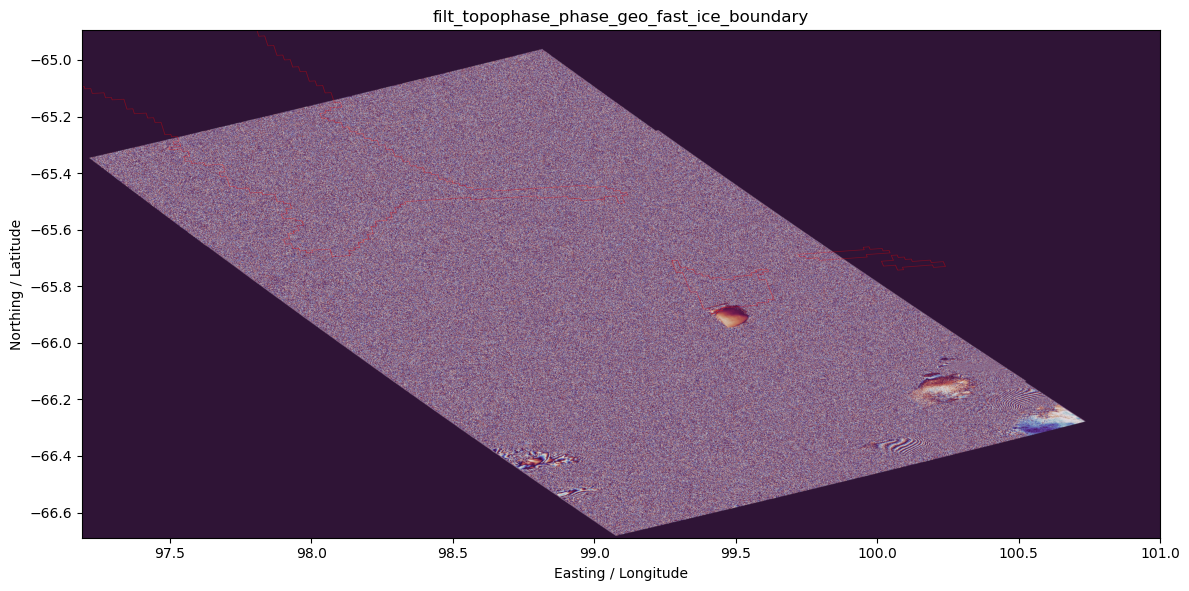

Saved PNG: output/filt_topophase_phase_geo_fast_ice_only.png


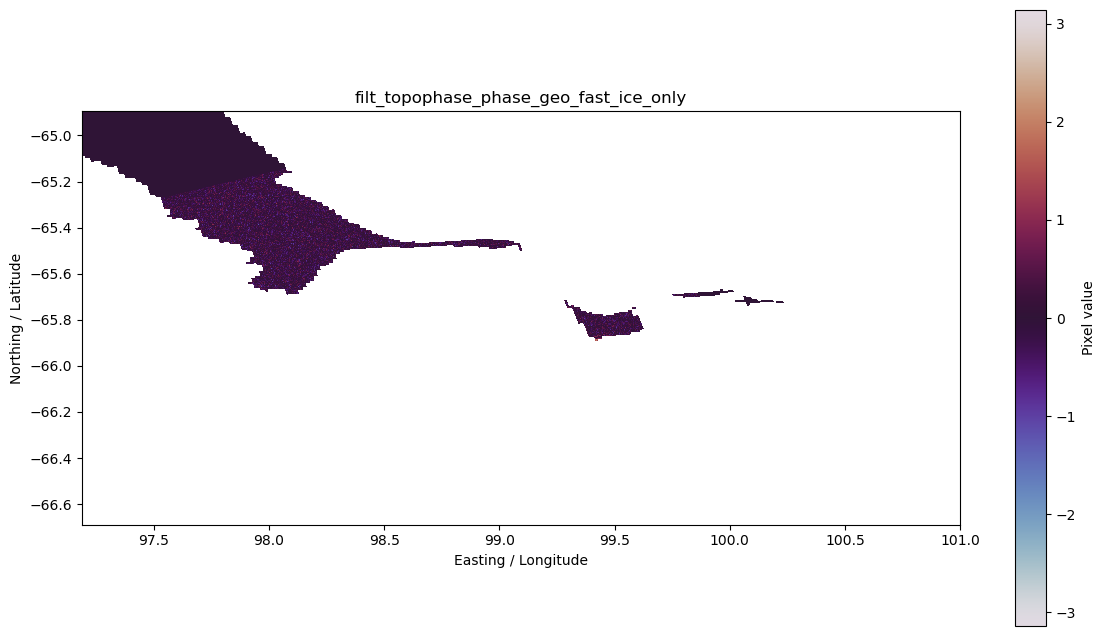

Saved PNG: output/topophase_amp_geo_fast_ice_boundary.png


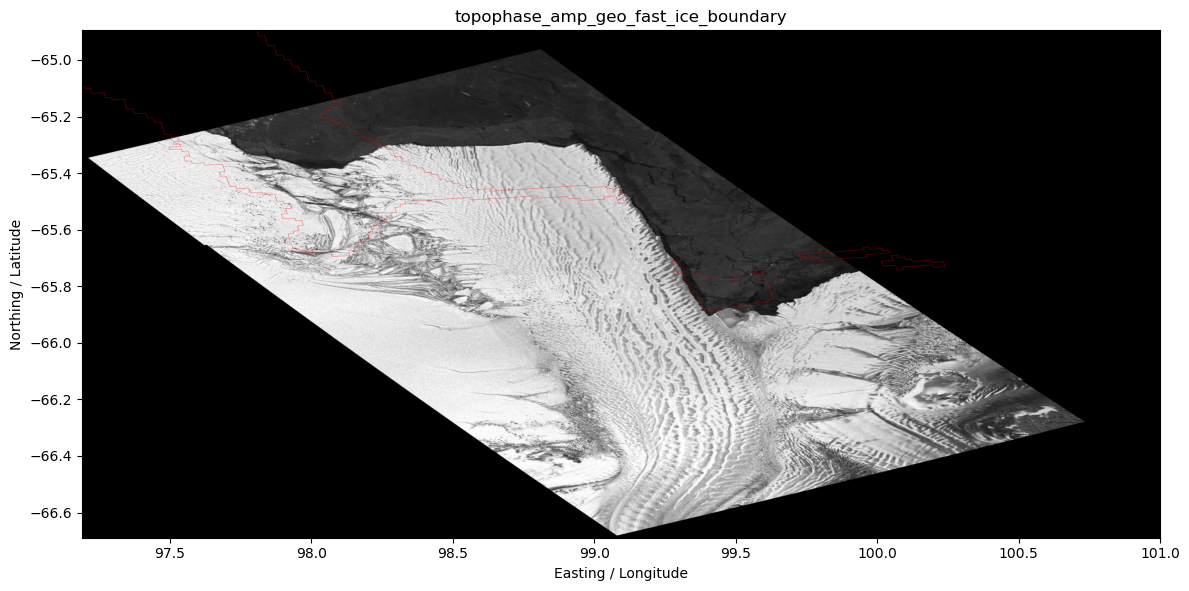

Saved PNG: output/topophase_amp_geo_fast_ice_only.png


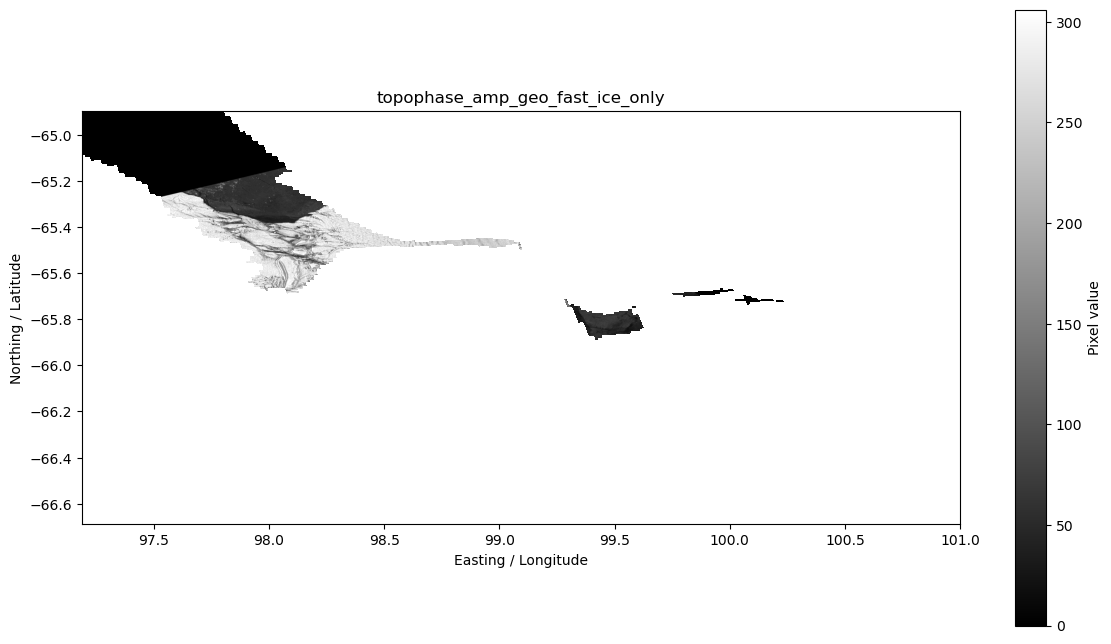

Saved PNG: output/topophase_coherence_geo_fast_ice_boundary.png


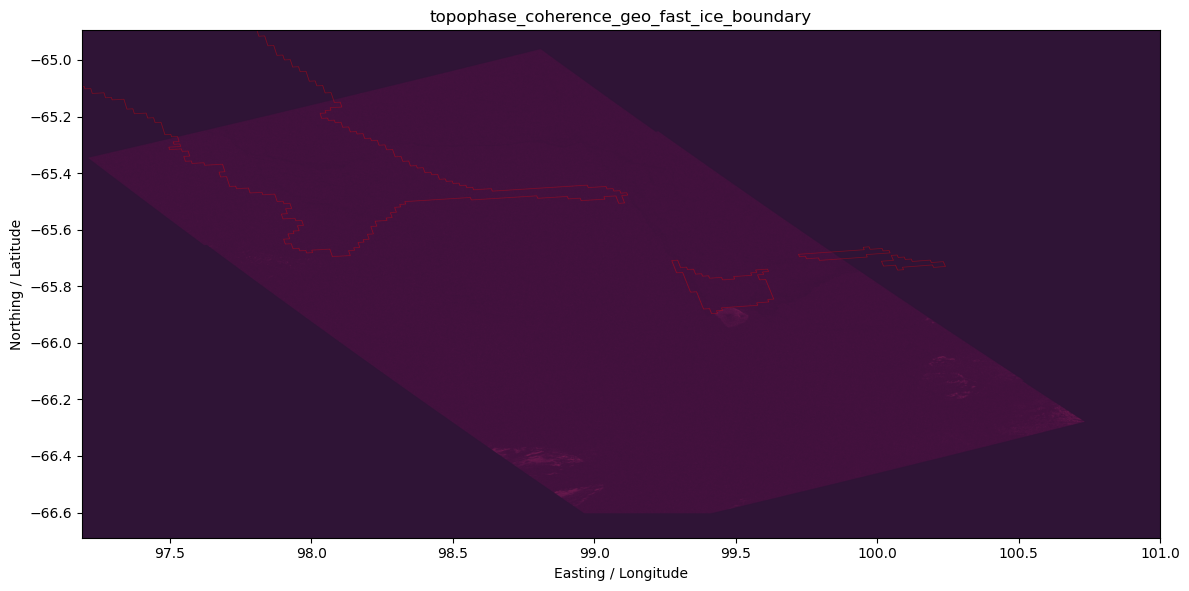

Saved PNG: output/topophase_coherence_geo_fast_ice_only.png


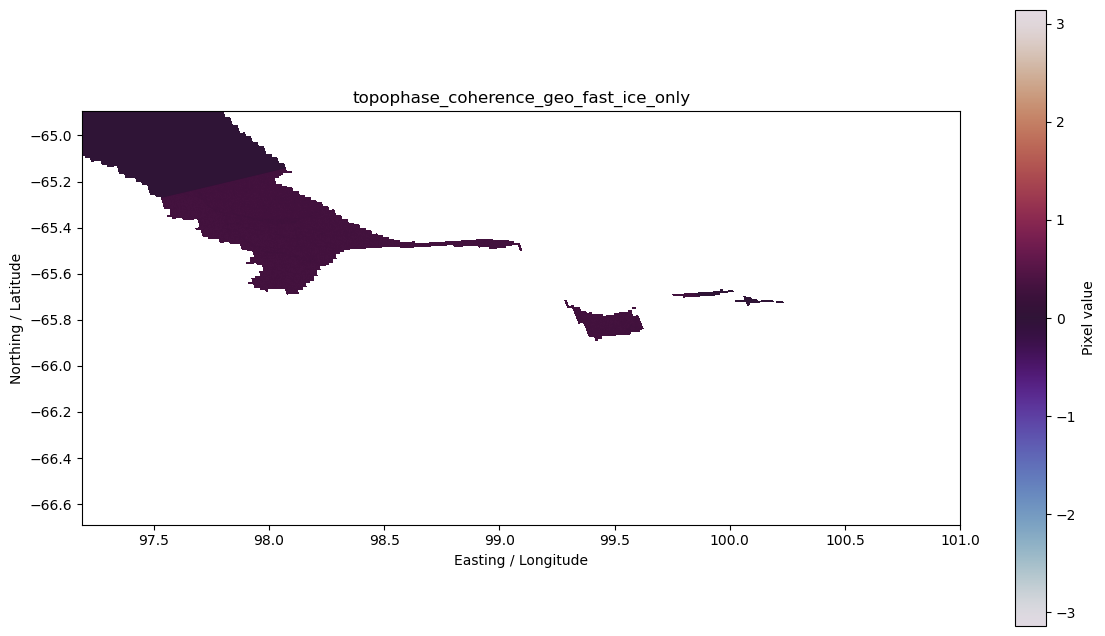

In [7]:
# Create and display PNG previews for the six output GeoTIFFs.
output_geotiffs = [
    output_dir / f"{Path(tif_name).stem}_{suffix}.tif"
    for tif_name in tif_files
    for suffix in ("fast_ice_boundary", "fast_ice_only")
]

for tif_path in output_geotiffs:
    if not tif_path.exists():
        print(f"Not found, skipped: {tif_path}")
        continue

    with rasterio.open(tif_path) as src:
        extent = [src.bounds.left, src.bounds.right,
                  src.bounds.bottom, src.bounds.top]

        fig, ax = plt.subplots(figsize=(12, 8))

        if src.count == 3:
            # RGB boundary product
            image = np.moveaxis(src.read(), 0, 2)
            ax.imshow(image, extent=extent, origin="upper")
        else:
            # Single-band fast-ice-only product
            image = src.read(1, masked=True)

            if "phase" in tif_path.name and "amp" not in tif_path.name:
                cmap, vmin, vmax = "twilight", -np.pi, np.pi
            elif "coherence" in tif_path.name:
                cmap, vmin, vmax = "viridis", 0.0, 1.0
            else:
                values = image.compressed()
                if values.size == 0:
                    plt.close(fig)
                    print(f"No valid pixels, skipped: {tif_path.name}")
                    continue
                vmin, vmax = np.nanpercentile(values, [2, 98])
                cmap = "gray"

            plotted = ax.imshow(
                image,
                cmap=cmap,
                vmin=vmin,
                vmax=vmax,
                extent=extent,
                origin="upper",
            )
            fig.colorbar(plotted, ax=ax, shrink=0.8, label="Pixel value")

        ax.set_title(tif_path.stem)
        ax.set_xlabel("Easting / Longitude")
        ax.set_ylabel("Northing / Latitude")
        fig.tight_layout()

        png_path = tif_path.with_suffix(".png")
        fig.savefig(png_path, dpi=300, bbox_inches="tight")
        print(f"Saved PNG: {png_path}")

        plt.show()
        plt.close(fig)

### Alignment checks

The notebook prints the CRS, bounds, and class-4 pixel counts before and after
reprojection. If the reprojected count is zero, check:

- that the exported fast-ice GeoTIFF has the correct CRS assigned;
- that its bounds overlap the InSAR GeoTIFF bounds; and
- that the source contains numeric category `4`.

In QGIS, set the project CRS to the InSAR GeoTIFF CRS and inspect layer
properties rather than assigning a new CRS manually.
